### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [4]:
# %pip install transformers


In [5]:
from transformers import ViTForImageClassification, ViTImageProcessor
import torch

In [6]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')
model.to(device)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1584.54it/s]


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [8]:
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

c:\Users\aziz1\OneDrive\Desktop\hsoub academy\ok\02_Google_Colab_Notebooks\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\aziz1\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [9]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

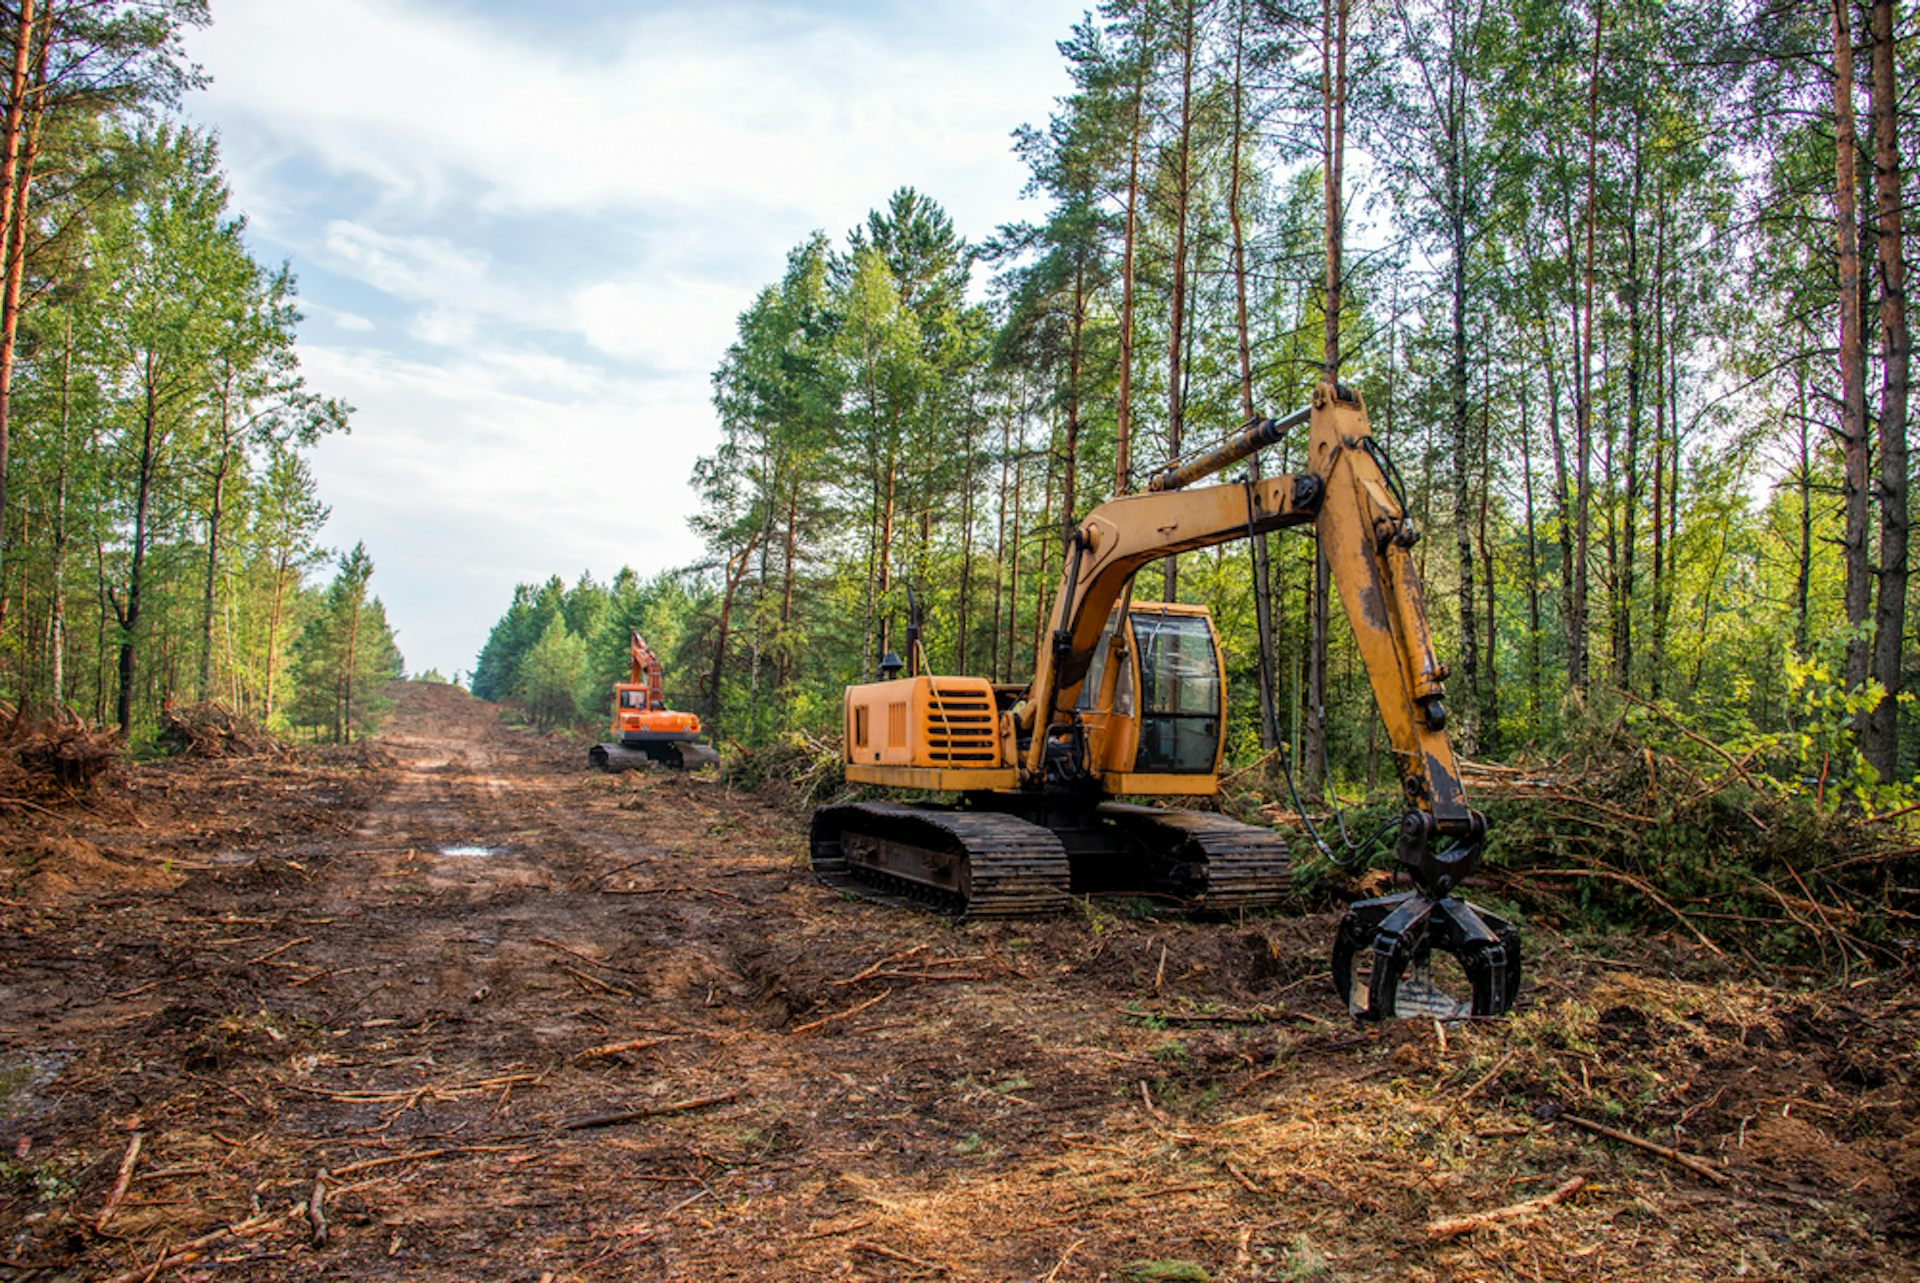

In [10]:
from PIL import Image

import os
image_path = 'crane.jpg' if os.path.exists('crane.jpg') else 'ViT/crane.jpg'
image = Image.open(image_path)
image

In [11]:
inputs = processor(images=image, return_tensors="pt").to(device)
pixel_values = inputs.pixel_values
pixel_values

tensor([[[[-0.4196, -0.2157, -0.1608,  ..., -0.2235,  0.5216,  0.5216],
          [-0.5059, -0.1137, -0.1765,  ..., -0.2235,  0.1294,  0.0118],
          [-0.4980, -0.5686, -0.2863,  ..., -0.3020,  0.1529, -0.0824],
          ...,
          [-0.5529, -0.5922, -0.5843,  ..., -0.2392, -0.2392, -0.4745],
          [-0.3490, -0.4431, -0.4196,  ..., -0.2863, -0.2549, -0.2941],
          [-0.6078, -0.5451, -0.4353,  ..., -0.1922, -0.2471, -0.1059]],

         [[-0.3882, -0.1373, -0.2784,  ..., -0.0824,  0.6863,  0.5216],
          [-0.6235, -0.0196, -0.2157,  ..., -0.0353,  0.2627, -0.0196],
          [-0.5843, -0.5451, -0.5216,  ..., -0.1137,  0.2706, -0.0902],
          ...,
          [-0.6235, -0.7098, -0.7490,  ..., -0.4510, -0.4745, -0.6392],
          [-0.4745, -0.5529, -0.5843,  ..., -0.4902, -0.4902, -0.4745],
          [-0.7333, -0.6627, -0.5686,  ..., -0.4118, -0.4902, -0.3412]],

         [[-0.2392,  0.0745, -0.3961,  ..., -0.2235,  0.6471,  0.6863],
          [-0.5608,  0.1686, -

In [12]:
import torch

with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits

prediction = logits.argmax(-1)
print("Predicted class:", model.config.id2label[prediction.item()])

Predicted class: crane
